# Metropolia Poznańska — mieszkańcy Poznania vs obwarzanka

Analiza klientów **zamieszkałych** w Poznaniu i 17 gminach przyległych (`lau_enr`), niezależnie od tego gdzie robią zakupy.

Filtr bazowy: `lau_enr IN (
    'BUK','CZERWONAK','DOPIEWO','KLESZCZEWO','KOMORNIKI','KORNIK','KOSTRZYN','LUBON',
    'MOSINA','MUROWANA GOSLINA','POBIEDZISKA','PUSZCZYKOWO','ROKIETNICA','STESZEW',
    'SUCHY LAS','SWARZEDZ','TARNOWO PODGORNE','POZNAN'
)`
Podział: `grupa_analizy` = **POZNAN** (mieszkańcy miasta) vs **OBWARZANEK** (mieszkańcy 17 gmin okalających).

Zakres analizy:
1. Statystyki podstawowe (liczba transakcji, karty, wolumen, średnia wartość transakcji)
2. Lokalizacja transakcji: w Poznaniu / w Polsce poza Poznaniem / za granicą — różnice średnich wartości
3. Dni robocze vs weekend, w Poznaniu vs poza Poznaniem
4. Godziny × skategoryzowane MCC (heatmapa) — osobno dla Poznania i obwarzanka
5. Zgrupowane pasma godzinowe × kategorie — wnioski przekrojowe

Silnik: DuckDB na `poznan_full_filtered.parquet` (bez wczytywania całości do pamięci).

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PATH = '/Users/ksiadzb/DataSprint/poznan/poznan_full_filtered.parquet'
OUT_DIR = '/Users/ksiadzb/DataSprint/poznan/metropolia'

GMINY_METRO = "(\n    'BUK','CZERWONAK','DOPIEWO','KLESZCZEWO','KOMORNIKI','KORNIK','KOSTRZYN','LUBON',\n    'MOSINA','MUROWANA GOSLINA','POBIEDZISKA','PUSZCZYKOWO','ROKIETNICA','STESZEW',\n    'SUCHY LAS','SWARZEDZ','TARNOWO PODGORNE','POZNAN'\n)"
FILTR_METRO = f"lau_enr IN {GMINY_METRO}"

GRUPA_CASE = "CASE WHEN lau_enr = 'POZNAN' THEN 'POZNAN' ELSE 'OBWARZANEK' END"

total = duckdb.sql(f"SELECT COUNT(*) FROM '{PATH}' WHERE {FILTR_METRO}").fetchone()[0]
print(f"Transakcje mieszkancow metropolii (Poznan + 17 gmin): {total:,}")


Transakcje mieszkancow metropolii (Poznan + 17 gmin): 41,284,471


## 1. Statystyki podstawowe: POZNAN vs OBWARZANEK

In [2]:
df_baza = duckdb.sql(f"""
    SELECT
        {GRUPA_CASE} AS grupa_analizy,
        COUNT(*) AS transakcje,
        COUNT(DISTINCT pymt_crd_acct_num_raw) AS karty,
        SUM(cs_tran_amt) AS wolumen,
        ROUND(SUM(cs_tran_amt) / COUNT(*), 2) AS srednia_transakcja,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT pymt_crd_acct_num_raw), 1) AS transakcji_na_karte
    FROM '{PATH}'
    WHERE {FILTR_METRO}
    GROUP BY 1
    ORDER BY 1
""").df()

df_baza.to_csv(f'{OUT_DIR}/01_statystyki_podstawowe.csv', index=False, encoding='utf-8-sig')
df_baza


,grupa_analizy,transakcje,karty,wolumen,srednia_transakcja,transakcji_na_karte
0,OBWARZANEK,16911978,144440,2.379607e+09,140.71,117.1
1,POZNAN,24372493,179360,2.773485e+09,113.80,135.9


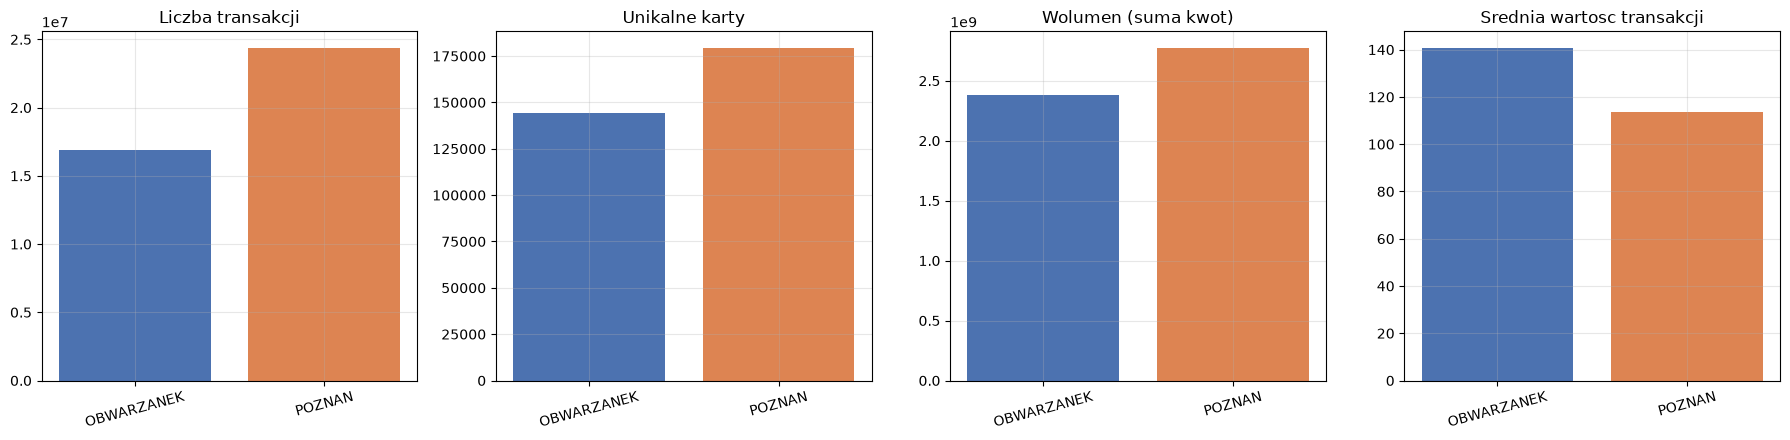

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
metryki = [
    ('transakcje', 'Liczba transakcji'),
    ('karty', 'Unikalne karty'),
    ('wolumen', 'Wolumen (suma kwot)'),
    ('srednia_transakcja', 'Srednia wartosc transakcji'),
]
kolory = ['#4C72B0', '#DD8452']
for ax, (col, title) in zip(axes, metryki):
    ax.bar(df_baza['grupa_analizy'], df_baza[col], color=kolory)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/01_statystyki_podstawowe.png', dpi=120)
plt.show()


## 2. Lokalizacja transakcji: w Poznaniu / Polska poza Poznaniem / za granicą

Podział wg **miejsca sprzedawcy** (nie miejsca zamieszkania), per grupa mieszkańców.

In [4]:
df_lokalizacja = duckdb.sql(f"""
    SELECT
        {GRUPA_CASE} AS grupa_analizy,

        SUM(CASE WHEN UPPER(TRIM(mrch_city_nm_raw)) LIKE '%POZNAN%' THEN 1 ELSE 0 END) AS transakcje_w_poznaniu,
        SUM(CASE WHEN UPPER(TRIM(mrch_city_nm_raw)) LIKE '%POZNAN%' THEN cs_tran_amt ELSE 0 END) AS wolumen_w_poznaniu,
        ROUND(SUM(CASE WHEN UPPER(TRIM(mrch_city_nm_raw)) LIKE '%POZNAN%' THEN cs_tran_amt ELSE 0 END)
              / NULLIF(SUM(CASE WHEN UPPER(TRIM(mrch_city_nm_raw)) LIKE '%POZNAN%' THEN 1 ELSE 0 END), 0), 2) AS srednia_w_poznaniu,

        SUM(CASE WHEN mrch_ctry_nm = 'POLAND' AND UPPER(TRIM(mrch_city_nm_raw)) NOT LIKE '%POZNAN%' THEN 1 ELSE 0 END) AS transakcje_polska_poza_poznaniem,
        SUM(CASE WHEN mrch_ctry_nm = 'POLAND' AND UPPER(TRIM(mrch_city_nm_raw)) NOT LIKE '%POZNAN%' THEN cs_tran_amt ELSE 0 END) AS wolumen_polska_poza_poznaniem,
        ROUND(SUM(CASE WHEN mrch_ctry_nm = 'POLAND' AND UPPER(TRIM(mrch_city_nm_raw)) NOT LIKE '%POZNAN%' THEN cs_tran_amt ELSE 0 END)
              / NULLIF(SUM(CASE WHEN mrch_ctry_nm = 'POLAND' AND UPPER(TRIM(mrch_city_nm_raw)) NOT LIKE '%POZNAN%' THEN 1 ELSE 0 END), 0), 2) AS srednia_polska_poza_poznaniem,

        SUM(CASE WHEN mrch_ctry_nm <> 'POLAND' THEN 1 ELSE 0 END) AS transakcje_za_granica,
        SUM(CASE WHEN mrch_ctry_nm <> 'POLAND' THEN cs_tran_amt ELSE 0 END) AS wolumen_za_granica,
        ROUND(SUM(CASE WHEN mrch_ctry_nm <> 'POLAND' THEN cs_tran_amt ELSE 0 END)
              / NULLIF(SUM(CASE WHEN mrch_ctry_nm <> 'POLAND' THEN 1 ELSE 0 END), 0), 2) AS srednia_za_granica

    FROM '{PATH}'
    WHERE {FILTR_METRO}
    GROUP BY 1
    ORDER BY 1
""").df()

df_lokalizacja.to_csv(f'{OUT_DIR}/02_lokalizacja_transakcji.csv', index=False, encoding='utf-8-sig')
df_lokalizacja


,grupa_analizy,transakcje_w_poznaniu,wolumen_w_poznaniu,srednia_w_poznaniu,transakcje_polska_poza_poznaniem,wolumen_polska_poza_poznaniem,srednia_polska_poza_poznaniem,transakcje_za_granica,wolumen_za_granica,srednia_za_granica
0,OBWARZANEK,4550283.0,6.950374e+08,152.75,11946846.0,1.606303e+09,134.45,414849.0,7.826693e+07,188.66
1,POZNAN,19355147.0,2.156019e+09,111.39,4432799.0,5.151977e+08,116.22,584547.0,1.022676e+08,174.95


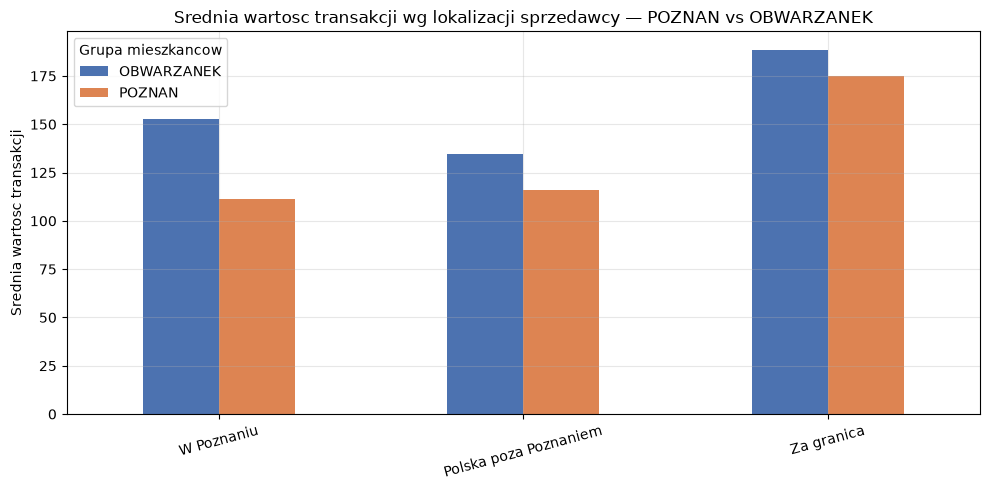

In [5]:
srednie = df_lokalizacja[['grupa_analizy', 'srednia_w_poznaniu', 'srednia_polska_poza_poznaniem', 'srednia_za_granica']]
srednie = srednie.set_index('grupa_analizy').T
srednie.index = ['W Poznaniu', 'Polska poza Poznaniem', 'Za granica']

fig, ax = plt.subplots()
srednie.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Srednia wartosc transakcji')
ax.set_title('Srednia wartosc transakcji wg lokalizacji sprzedawcy — POZNAN vs OBWARZANEK')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Grupa mieszkancow')
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/02_srednie_wg_lokalizacji.png', dpi=120)
plt.show()


## 3. Dni robocze vs weekend, w Poznaniu vs poza Poznaniem

In [6]:
df_dni = duckdb.sql(f"""
    SELECT
        {GRUPA_CASE} AS grupa_analizy,
        CASE WHEN isodow(CAST(prch_dt AS DATE)) IN (6,7) THEN 'WEEKEND' ELSE 'DZIEN ROBOCZY' END AS typ_dnia,
        CASE WHEN UPPER(TRIM(mrch_city_nm_raw)) LIKE '%POZNAN%' THEN 'W POZNANIU' ELSE 'POZA POZNANIEM' END AS lokalizacja,
        COUNT(*) AS transakcje,
        SUM(cs_tran_amt) AS wolumen,
        ROUND(SUM(cs_tran_amt) / COUNT(*), 2) AS srednia_transakcja,
        COUNT(DISTINCT pymt_crd_acct_num_raw) AS unikalne_karty
    FROM '{PATH}'
    WHERE {FILTR_METRO}
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
""").df()

df_dni.to_csv(f'{OUT_DIR}/03_dni_robocze_weekend.csv', index=False, encoding='utf-8-sig')
df_dni


,grupa_analizy,typ_dnia,lokalizacja,transakcje,wolumen,srednia_transakcja,unikalne_karty
0,OBWARZANEK,DZIEN ROBOCZY,POZA POZNANIEM,9426573,1.273714e+09,135.12,132294
1,OBWARZANEK,DZIEN ROBOCZY,W POZNANIU,3569152,5.383420e+08,150.83,116248
2,OBWARZANEK,WEEKEND,POZA POZNANIEM,2935122,4.108557e+08,139.98,115227
3,OBWARZANEK,WEEKEND,W POZNANIU,981131,1.566954e+08,159.71,93213
4,POZNAN,DZIEN ROBOCZY,POZA POZNANIEM,3613363,4.384209e+08,121.33,157095
5,POZNAN,DZIEN ROBOCZY,W POZNANIU,15215472,1.677986e+09,110.28,157264
6,POZNAN,WEEKEND,POZA POZNANIEM,1403983,1.790444e+08,127.53,129663
7,POZNAN,WEEKEND,W POZNANIU,4139675,4.780331e+08,115.48,136660


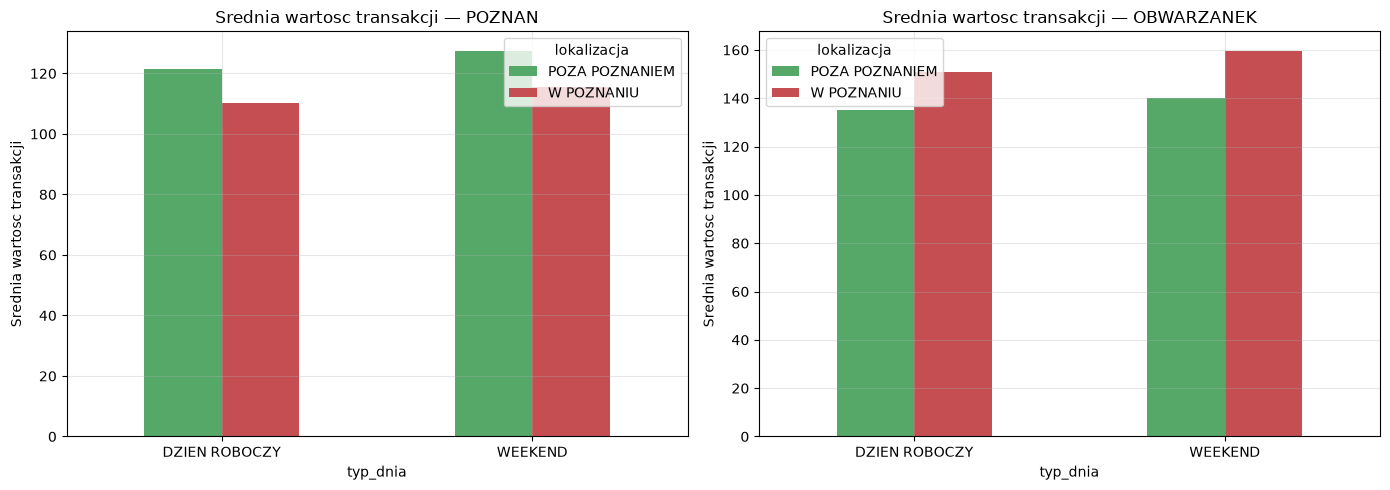

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grupa in zip(axes, ['POZNAN', 'OBWARZANEK']):
    sub = df_dni[df_dni['grupa_analizy'] == grupa]
    piv = sub.pivot(index='typ_dnia', columns='lokalizacja', values='srednia_transakcja')
    piv.plot(kind='bar', ax=ax, color=['#55A868', '#C44E52'])
    ax.set_title(f'Srednia wartosc transakcji — {grupa}')
    ax.set_ylabel('Srednia wartosc transakcji')
    ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/03_dni_robocze_weekend.png', dpi=120)
plt.show()


## 4. Godziny × skategoryzowane MCC — heatmapa (POZNAN vs OBWARZANEK)

In [8]:
MCC_CASE = """
    CASE
            WHEN mrch_catg_nm_u IN ('GROCERY STORES/SUPERMARKETS') THEN 'Duże supermarkety'
            WHEN mrch_catg_nm_u IN ('MISC FOOD STORES - DEFAULT') THEN 'Małe sklepy spożywcze'
            WHEN mrch_catg_nm_u IN ('EATING PLACES AND RESTAURANTS') THEN 'Restauracje i miejsca do jedzenia'
            WHEN mrch_catg_nm_u IN ('SERVICE STATIONS') THEN 'Stacje benzynowe'
            WHEN mrch_catg_nm_u IN ('FAST FOOD RESTAURANTS') THEN 'Fast Foody'
            WHEN mrch_catg_nm_u IN ('BAKERIES') THEN 'Piekarnie i cukiernie'
    
            WHEN mrch_catg_nm_u IN (
                'HOTELS/MOTELS/RESORTS', 'SHERATON', 'HOTEL IBIS', 'RADISSON HOTEL', 'NOVOTEL', 'HOTEL MERCURE', 'MARRIOTT', 'HILTON', 'PARK INNS INTERNATIONAL', 'HOLIDAY INN', 'DOUBLETREE HOTEL', 'SCANDIC HOTELS', 'RADISSON BLU', 'COURTYARD BY MARRIOTT', 'HAMPTON INN', 'DOLCE HOTELS AND RESORTS', 'PREMIER TRAVEL INNS', 'SOFITEL HOTELS', 'HOTELES MELIA', 'REGENT INTERNATIONAL HOTELS', 'MARATIM', 'WESTIN', 'NICKELODEON SUITES', 'CROWNE PLAZA HOTELS', 'DISNEY RESORTS', 'STEIGENBERGER', 'TOWN & COUNTRY RESORT/CONV CTR', 'HILTON GARDEN INN', 'CAMPANILE', 'HILTON INTERNATIONAL', 'PARK PLAZA HOTEL', 'WYNDHAM', 'TOWNEPLACE SUITES', 'DORINT HOTELS', 'MOEVENPICK HOTELS', 'TRAVELODGE', 'SONESTA HOTEL', 'RESIDENCE INN', 'AMERISUITES', 'AUTOGRAPH', 'FOUR SEASONS', 'FAIRMONT HOTEL', 'SPRINGHILL SUITES', 'MILLENNIUM HOTELS', 'DAYS INN', 'SUPER 8 MOTEL', 'W HOTELS', 'CAESAR''S HOTEL AND CASINO', 'OXFORD SUITES', 'HOTEL INDIGO', 'FAIRFIELD INN', 'HOSPITALITY INNS', 'MOTEL 6', 'FLAMINGO HOTELS', 'PRINCE HOTEL', 'PARIS LAS VEGAS HOTEL', 'LA QUINTA INN AND SUITES', 'ECONOLODGE', 'EXCALIBUR HOTEL AND CASINO', 'WALDORF', 'RIO HOTELS', 'QUALITY INN', 'HOMEWOOD SUITES', 'VENETIAN RESORT HOTEL CASINO', 'EMBASSY SUITES', 'PULLMAN INTERNATIONAL HOTELS', 'PROTEA HOTELS', 'BALLY''S HOTEL AND CASINO', 'DRURY INN', 'COUNTRY INN BY CARLSON', 'SOUTHERN SUN HOTELS', 'IMPERIAL LONDON HOTELS', 'CARLTON HOTELS', 'FIRST HOSPITALITY HOTELS', 'BELLAGIO', 'AMERICAS BEST VALUE INN', 'CHATEAU ELAN WINERY AND RESORT', 'CLARION HOTEL', 'STRATOSPHERE HOTEL AND CASINO', 'MANDARIN ORIENTAL HOTEL', 'CURIO HOTELS', 'RELAX INNS', 'CLUBCORP/CLUBRESORTS', 'OMNI HOTEL', 'RAMADA INN', 'LOEWS HOTEL', 'DELTA HOTEL', 'MICROTEL INNS & SUITES', 'RED ROOF INN', 'SOKOS HOTELS', 'CITY LODGE HOTELS', 'SANDMAN HOTELS', 'SOHO GRAND HOTEL', 'ROYAL HOTELS', 'GREAT WOLF', 'CANOPY HOTELS', 'ST. REGIS HOTEL', 'RENAISSANCE HOTELS', 'PENINSULA HOTELS', 'HOME2 SUITES', 'HARRAH''S HOTELS AND CASINOS', 'BEST WESTERN', 'INTER-CONTINENTAL', 'GOLDEN TULIP', 'HYATT', 'THE RITZ-CARLTON', 'MOXY', 'GAYLORD PALMS', 'ALOFT', 'SHANGRI-LA INTERNATIONAL', 'HYATT PLACE', 'LA MANSION DEL RIO', 'JUMEIRAH ESSEX HOUSE', 'TRAILER PARKS AND CAMPGROUNDS'
            ) THEN 'Baza noclegowa i hotele'
    
            WHEN mrch_catg_nm_u IN (
                'FREEZER/MEAT LOCKERS', 'BARS/TAVERNS/LOUNGES/DISCOS', 'CATERERS'
            ) THEN 'Zakupy spożywcze i gastronomia (pozostałe)'
    
            WHEN mrch_catg_nm_u IN (
                'CAR WASHES', 'PARKING LOTS,METERS,GARAGES', 'TOLLS AND BRIDGE FEES', 'PASSENGER RAILWAYS', 'AUTOMATED FUEL DISPENSERS', 'AUTO SERVICE SHOPS/NON DEALER', 'TAXICABS/LIMOUSINES', 'BUS LINES', 'CAR & TRUCK DEALERS/NEW/USED', 'MISC REPAIR SERVICES', 'RYANAIR', 'MOTOR FREIGHT CARRIERS', 'REAL EST AGNTS & MGRS RENTALS', 'AUTOMOBILE RENTAL AGENCY', 'MOTORCYCLE DEALERS', 'FUEL DEALERS', 'AIRLINES, AIR CARRIERS', 'TIRE RETREAD/REPAIR SHOPS', 'AUTO BODY REPAIR SHOPS', 'MISC AUTO DEALERS - DEFAULT', 'STEAMSHIP/CRUISE LINES', 'RADIO/TV/STEREO REPAIR SHOP', 'HEATING, PLUMBING, AIR COND', 'SMALL APPLIANCE REPAIR DEF', 'ELECTRIC VEHICLE CHARGING', 'LOT (POLAND)', 'AIR COND/REFRIG REPAIR SHOP', 'CAR & TRUCK DEALERS/USED ONLY', 'MOTOR HOME/RV RENTALS', 'TRUCK/UTILITY TRAILER RENTALS', 'SIXT CAR RENTAL', 'AVIS RENT-A-CAR', 'TOWING SERVICES', 'HERTZ RENT-A-CAR', 'BOAT DEALERS', 'SAS', 'ENTERPRISE RENT-A-CAR', 'AUTO ASSOCIATIONS', 'KLM', 'AFFILIATED AUTO RENTAL', 'LUFTHANSA', 'EASYJET', 'EMIRATES AIRLINES', 'ALAMO RENT-A-CAR', 'AIR ASTANA', 'BUDGET RENT-A-CAR', 'NATIONAL CAR RENTAL', 'TURKISH AIRLINES', 'DOLLAR RENT-A-CAR', 'IBERIA', 'SN BRUSSELS AIRLINES', 'SWISS INTERNATIONAL AIRLINES', 'AMERICAN', 'QANTAS', 'LAN AIR', 'WIZZ AIR', 'BRITISH AIRWAYS', 'UNITED', 'THRIFTY CAR RENTAL', 'AGENCY RENT-A-CAR', 'AIR FRANCE', 'AVIANCA', 'DELTA', 'AERO ARGENT', 'CEBU PACIFIC AIRLINES', 'JETSTAR AIRWAYS', 'HAWAIIANAIR', 'AIR ALGERIE', 'QATAR AIRWAYS', 'NORWEGIAN AIR SHUTTLE', 'EGYPTAIR', 'PAL AIR', 'BRAATHENS RGNL AIRLINES (BRA)', 'PAYLESS CAR RENTAL', 'COPA', 'EUROP CAR'
            ) THEN 'Transport i motoryzacja (pozostałe)'
    
            WHEN mrch_catg_nm_u IN (
                'COSMETIC STORES', 'DRUG STORES & PHARMACIES', 'BEAUTY/BARBER SHOPS', 'MED/HEALTH SERVICES - DEF', 'DENTISTS/ORTHODONTISTS', 'VETERINARY SERVICES', 'DOCTORS & PHYSICIANS', 'HEALTH & BEAUTY SPAS', 'OPTICIANS', 'HOSPITALS', 'DRUGS/DRUGGISTS SUNDRIES', 'DENTAL/LAB/MED EQUIPMENT', 'MASSAGE PARLORS', 'MEDICAL/DENTAL LABS', 'PODIATRISTS/CHIROPODISTS', 'TESTING LABS (NON-MEDICAL)', 'OSTEOPATHS', 'NURSING/PERSONAL CARE FAC', 'CHIROPRACTORS'
            ) THEN 'Zdrowie i uroda'
    
            WHEN mrch_catg_nm_u IN (
                'VARIETY STORES', 'FAMILY CLOTHING STORES', 'CANDY/NUT/CONFECTION STORES', 'DISCOUNT STORES', 'HOME SUPPLY WAREHOUSE STORES', 'MENS/WOMENS CLOTHING STORES', 'DEPARTMENT STORES', 'LUMBER/BUILD. SUPPLY STORES', 'MISC SPECIALTY RETAIL', 'FLORISTS', 'BOOK STORES', 'PKG STORES/BEER/WINE/LIQUOR', 'PET STORES/FOOD & SUPPLY', 'ELECTRONICS STORES', 'FURNITURE/EQUIP STORES', 'CIGAR STORES/STANDS', 'SHOE STORES', 'MISC GENERAL MERCHANDISE', 'NURSERIES, LAWN/GARDEN SUPPLY', 'GIFT, CARD, NOVELTY STORES', 'DUTY FREE STORES', 'JEWELRY STORES', 'STATIONERY STORES', 'WOMENS READY TO WEAR STORES', 'AUTOMOTIVE PARTS STORES', 'DAIRY PRODUCT STORES', 'WOMENS ACCESS/SPECIALTY', 'MISC APPAREL/ACCESS STORES', 'USED MERCHANDISE STORES', 'HOUSEHOLD APPLIANCE STORES', 'HARDWARE STORES', 'MEN/BOYS CLOTHING/ACC STORES', 'FABRIC STORES', 'LUGGAGE/LEATHER STORES', 'PHOTO STUDIOS', 'PHOTOFINISH LABS/DEV', 'FLORIST SUPPLIES/NURSERY STOCK', 'BICYCLE SHOPS/SALES/SERVICE', 'STATIONERY/OFFICE SUPPLIES', 'DRAPERY & UPHOLSTERY STORES', 'HARDWARE EQUIPMENT/SUPPLIES', 'ARTIST/CRAFT SHOPS', 'GLASS/PAINT/WALLPAPER STORES', 'BOOKS/PERIODICALS/NEWSPAPERS', 'SHOE REPAIR/SHINE/HAT CLEAN', 'GLASSWARE/CRYSTAL STORES', 'FINANCIAL INST/MERCHANDISE', 'RELIGIOUS GOODS STORES', 'MOTOR VEHICLE SUPPLY/NEW PARTS', 'COMPUTER SOFTWARE STORES', 'UNIFORMS & COMMERCIAL CLOTHING', 'WATCH/CLOCK/JEWELRY REPAIR', 'OFFICE/PHOTO EQUIPMENT', 'CAMERA & PHOTO SUPPLY STORES', 'MUSIC STORES/PIANOS', 'ELEC RAZOR STORES/SALE/SERV', 'POSTAGE STAMPS', 'FLOOR COVERING STORES', 'COMMERCIAL PHOTO/ART/GRAPH', 'PAINT, VARNISHES & SUPPLIES', 'RECORD STORES', 'ANTIQUE SHOPS', 'PRECIOUS STONES/METALS/JEWELRY', 'AUTOMOTIVE TIRE STORES', 'ACCOUNTANTS/AUDITORS/BOOKPR', 'PETROLEUM/PETROLEUM PRODUCTS', 'AUTO PAINT SHOPS', 'DVD/VIDEO TAPE RENTAL STORES', 'STAMP & COIN STORES', 'NON-FIN INST-STORED VALUE CARD', 'MARINAS, SERVICE & SUPPLY', 'WIG AND TOUPEE STORES', 'COMMERCIAL FURNITURE', 'CLOTHING/RENT/COSTUME/UNIFO', 'DIGITAL GOODS APP(EXCL GAMES)', 'ANTIQUE REPRODUCTION STORES', 'CARPET/UPHOLSTERY CLEANING', 'FURNITURE REUPHOLSTERY/REPAIR', 'COMBINATION CATALOG & RETAIL', 'FIREPLACES & ACCESSORIES', 'DIGITAL GOODS GAMES', 'DIGITAL GOODS BOOKSMOVIEMUSIC', 'CATALOG MERCHANT', 'CHILDREN/INFANTS WEAR STORES', 'HOBBY, TOY & GAME STORES'
            ) THEN 'Zakupy detaliczne i dom'
    
            WHEN mrch_catg_nm_u IN (
                'LOCAL COMMUTER TRANSPORT', 'GOVT-OWNED LOTTERIES (NON-US)', 'RECREATION SERVICES', 'SPORTING GOODS STORES', 'WHOLESALE CLUBS', 'MEMBER CLUBS/SPORT/REC/GOLF', 'MOTION PICTURE THEATRES', 'AMUSEMENT PARKS/CIRCUS', 'SPORTING/RECREATIONAL CAMPS', 'TOURIST ATTRACTIONS AND XHBT', 'TRANSPORTATION SVCS - DEFAULT', 'BANDS/ORCHESTRAS/ENTERTAIN', 'SPORTS/RIDING APPAREL STORES', 'COMMERCIAL/PRO SPORTS', 'THEATRICAL PRODUCERS', 'BOWLING ALLEYS', 'BETTING/TRACK/CASINO/LOTTO', 'VIDEO GAME ARCADES/ESTABLISH', 'BILLIARD/POOL ESTABLISHMENT', 'VIDEO AMUSEMENT GAME SUPPLY', 'SWIMMING POOLS/SALES/SERV', 'AQUARIUMS/SEAQUARIUMS', 'ART DEALERS & GALLERIES', 'CAMPER TRAILER DEALER', 'ARCADE', 'GOVERNMENT OWNED LOTTERIES', 'TAROM ROMANIAN AIR TRANSPORT', 'DANCE HALLS/STUDIOS/SCHOOLS'
            ) THEN 'Rozrywka, kultura i rekreacja'
    
            WHEN mrch_catg_nm_u IN (
                'NEWS DEALERS/NEWSSTANDS', 'WIRE TRANSFER MONEY ORDER', 'UTILITIES/ELEC/GAS/H2O/SANI', 'GOV''T SERV - DEFAULT', 'COURIER SERVICES', 'MISC HOME FURNISHING SPECIALTY', 'MISC PERSONAL SERV - DEF', 'TELECOMMUNICATION EQUIPMENT', 'QUICK COPY/REPRO SERVICES', 'INSURANCE SALES/UNDERWRITE', 'BUSINESS SERVICES - DEFAULT', 'TAX PAYMENTS', 'PROFESSIONAL SERVICES - DEF', 'COMPUTER PROGRAM/SYS DESIGN', 'LAUNDRIES-FAMILY/COMMERCIAL', 'CHARITABLE/SOC SERVICE ORGS', 'MISC PUBLISHING & PRINTING', 'ELECTRICAL PARTS/EQUIPMENT', 'RELIGIOUS ORGANIZATIONS', 'DIRECT SELL/DOOR-TO-DOOR', 'CONSTRUCTION MATERIALS - DEF', 'AGRICULTURAL CO-OPERATIVE', 'TRAVEL AGENCIES', 'LEGAL SERVICES ATTORNEYS', 'PLUMBING/HEATING EQUIPMENT', 'ORTHOPEDIC GOODS', 'COURT COSTS/ALIMONY/SUPPORT', 'TAILOR/SEAMSTRESS/ALTERS', 'PUBLIC WAREHOUSING', 'CHEMICALS/ALLIED PRODS - DEF', 'SPEC CONTRACTORS - DEFAULT', 'FINES', 'NON-DURABLE GOODS - DEFAULT', 'DRY CLEANERS', 'LAUNDRY/CLEANING/GARMENT SV', 'GEN CONTRACTORS RESIDENTL/COML', 'COUNSELING SERVICE - ALL', 'OPTOMETRISTS/OPHTHALMOLOGISTS', 'ADVERTISING SERVICES', 'NON-FIN INST/FC/MO/TC', 'LANDSCAPE/HORTICULTURAL SER', 'PAWN SHOPS', 'INDUSTRIAL SUPPLIES - DEF', 'DURABLE GOODS - DEFAULT', 'MEMBER ORGANIZATIONS - DEF', 'EQUIP/FURN RENT/LEASE SERV', 'COMPUTERS/PERIPHERALS/SOFTWARE', 'SPECIALTY CLEANING/POLISHING', 'COMPUTER MAINT/SVCS - DEF', 'CARPENTRY', 'CLEAN/MAINT/JANITORIAL SERV', 'COMMERCIAL EQUIPMENT - DEFAULT', 'COLLEGES/UNIV/JC/PROFESSION', 'AIRPORTS/FIELDS/TERMINALS', 'METAL SERVICE CENTERS', 'MGMT/CONSULT/PUBLIC REL SER', 'PIECE GOODS/NOTIONS/DRY GOODS', 'FUNERAL SERVICE/CREMATORIES', 'COMMERCIAL FOOTWEAR', 'CABLE, SAT, PAY TV/RADIO SVCS', 'ELECTRICAL CONTRACTORS', 'TELECOMMUNICATION SERVICES', 'MASONRY/TILE/PLASTER/INSUL', 'RAILROADS', 'PUBLIC GOLF COURSES', 'HEARING AID/SALES/SERVICE', 'BOAT RENTALS AND LEASING', 'CIVIC/SOCIAL/FRATERNAL ASSC', 'FURRIERS AND FUR SHOPS', 'EMPLOYMENT/TEMP HELP AGEN', 'ROOFING/SIDING/SHEET METAL', 'ARCHITECTURAL/ENG/SURVEY', 'INTRA-GOVERNMENT PURCHASES', 'OTHER DIRECT MARKETERS', 'INVALID MERCHANT CATEGORY', 'AMBULANCE SERVICE', 'COMPUTER NETWORK/INFO SVCS', 'INFORMATION RETRIEVAL SERVICES', 'TYPESETTING/PLATE MAKING ETC', 'WRECKING SALVAGE YARDS', 'DETECTIVE/PROTECTIVE AGEN', 'TAX PREPARATION SERVICE', 'BAIL AND BOND PAYMENTS', 'TIMESHARES', 'STENOGRAPHIC SERVICES', 'BUYING/SHOPPING SERVICES', 'DIRECT MARKETING INSURANCE SVC', 'FILMS/VIDEO PRODUCTION/DIST', 'DATING & ESCORT SERVICES', 'ONLINE MARKETPLACES', 'SECURITIES BROKERS/DEALERS', 'MOTOR HOME DEALERS', 'DIRECT MKTG-TRAVEL RELATED ARR', 'TENT AND AWNING SHOPS', 'CONTRACTORS - CONCRETE', 'CONTINUITY/SUBSCRIPTION MERCHT', 'WELDING SERVICES', 'POLITICAL ORGANIZATIONS', 'MOBILE HOME DEALERS', 'THE RITZ-CARLTON', 'EXTERMINATING/DISINFECT SERV', 'MOXY', 'SNOWMOBILE DEALERS', 'TELEGRAPH SERVICES', 'LARGE DIGITAL GOODS MERCHANT', 'CONSUMER CR REPORTING AGEN', 'FLY DUBAI', 'MERIDIEN', 'OUTBOUND TELEMARKETING MERCHNT', 'GAYLORD PALMS', 'ALOFT', 'SHANGRI-LA INTERNATIONAL', 'COLLECTION AGENCIES', 'TYPEWRITER/SALES/SERVICE', 'HYATT PLACE', 'LA MANSION DEL RIO', 'JUMEIRAH ESSEX HOUSE', 'SCHOOLS - DEFAULT', 'TRADE/VOCATIONAL SCHOOLS', 'CHILD CARE SERVICES', 'ELEMENTARY/SECONDARY SCHOOLS', 'BUSINESS/SECRETARIAL SCHOOL', 'CORRESPONDENCE SCHOOLS'
            ) THEN 'Usługi, finanse i opłaty urzędowe'
    
            ELSE 'Inne'
        END
"""

df_godz_mcc = duckdb.sql(f"""
    WITH src AS (
        SELECT
            UPPER(TRIM(mrch_catg_nm)) AS mrch_catg_nm_u,
            CAST(SUBSTR(tran_id_gmt_tm, 1, 2) AS INTEGER) AS godzina,
            {GRUPA_CASE} AS grupa_analizy,
            cs_tran_amt
        FROM '{PATH}'
        WHERE {FILTR_METRO}
    )
    SELECT
        grupa_analizy,
        godzina,
        {MCC_CASE} AS kategoria_glowna,
        COUNT(*) AS transakcje,
        SUM(cs_tran_amt) AS wolumen
    FROM src
    GROUP BY 1, 2, 3
""").df()

df_godz_mcc.to_csv(f'{OUT_DIR}/04_godziny_x_mcc.csv', index=False, encoding='utf-8-sig')
print('Liczba wierszy:', len(df_godz_mcc))
df_godz_mcc.head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Liczba wierszy: 624


,grupa_analizy,godzina,kategoria_glowna,transakcje,wolumen
0,POZNAN,17,Duże supermarkety,444737,5.131514e+07
1,OBWARZANEK,8,Zakupy spożywcze i gastronomia (pozostałe),39832,3.491681e+06
2,OBWARZANEK,0,"Rozrywka, kultura i rekreacja",89928,1.208401e+07
3,OBWARZANEK,9,Duże supermarkety,256943,3.703963e+07
4,POZNAN,22,Zakupy spożywcze i gastronomia (pozostałe),17431,1.357638e+06
5,POZNAN,7,Małe sklepy spożywcze,222118,1.000868e+07
6,POZNAN,11,Małe sklepy spożywcze,334056,1.636546e+07
7,POZNAN,15,Zdrowie i uroda,171943,3.369611e+07
8,POZNAN,15,Fast Foody,80426,5.212074e+06
9,OBWARZANEK,8,Małe sklepy spożywcze,155013,9.727028e+06


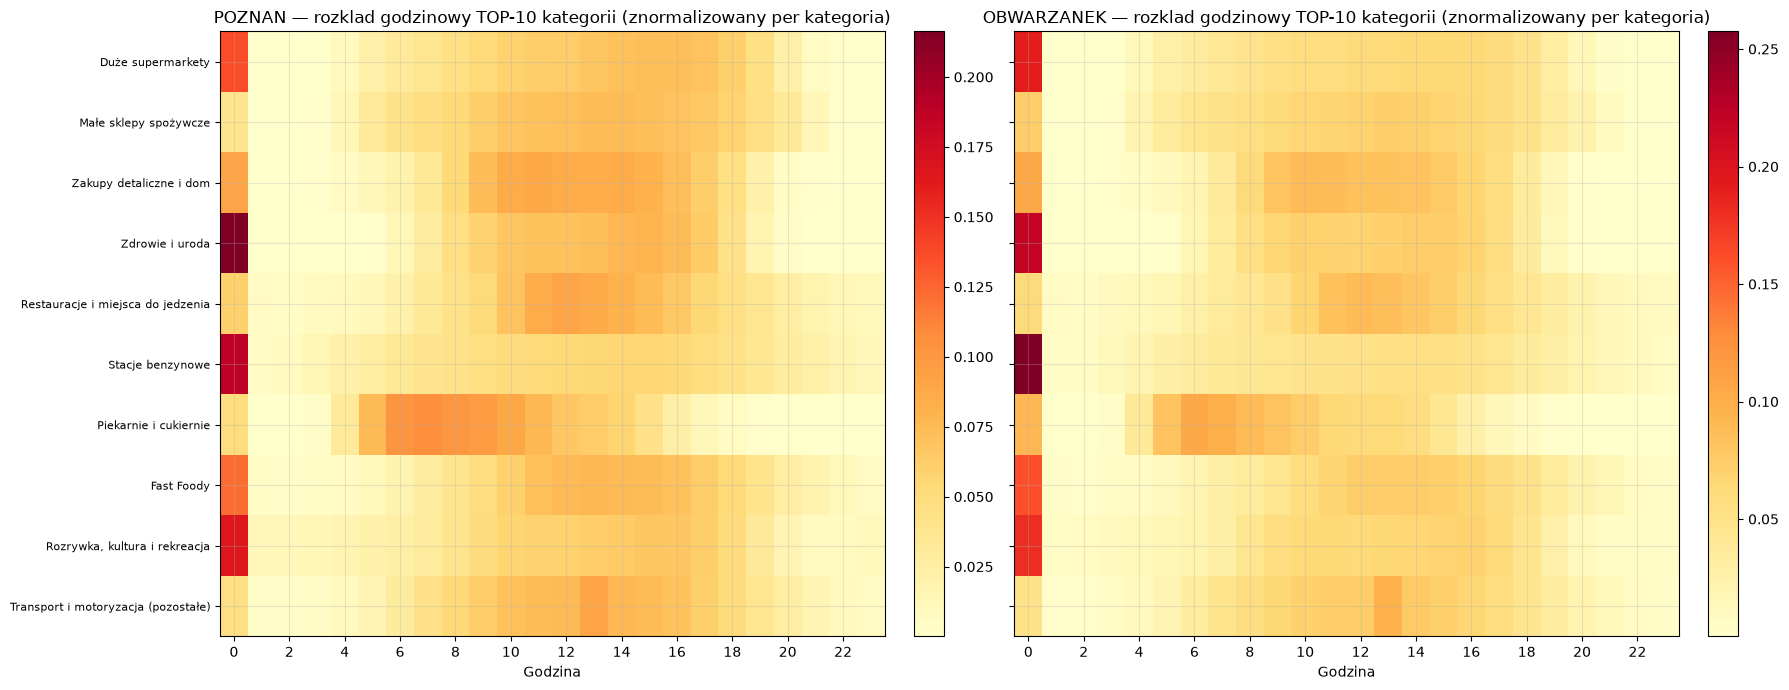

In [9]:
top_kat = df_godz_mcc.groupby('kategoria_glowna')['transakcje'].sum().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
for ax, grupa in zip(axes, ['POZNAN', 'OBWARZANEK']):
    sub = df_godz_mcc[(df_godz_mcc['grupa_analizy'] == grupa) & (df_godz_mcc['kategoria_glowna'].isin(top_kat))]
    piv = sub.pivot_table(index='kategoria_glowna', columns='godzina', values='transakcje', aggfunc='sum', fill_value=0)
    piv = piv.reindex(top_kat)
    # normalizacja per wiersz (rozklad godzinowy danej kategorii, nie wolumen absolutny)
    piv_norm = piv.div(piv.sum(axis=1), axis=0)
    im = ax.imshow(piv_norm.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels(range(0, 24, 2))
    ax.set_yticks(range(len(piv_norm)))
    ax.set_yticklabels(piv_norm.index, fontsize=8)
    ax.set_xlabel('Godzina')
    ax.set_title(f'{grupa} — rozklad godzinowy TOP-10 kategorii (znormalizowany per kategoria)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/04_heatmapa_godziny_mcc.png', dpi=120)
plt.show()


## 5. Zgrupowane pasma godzinowe × kategorie — przekrój

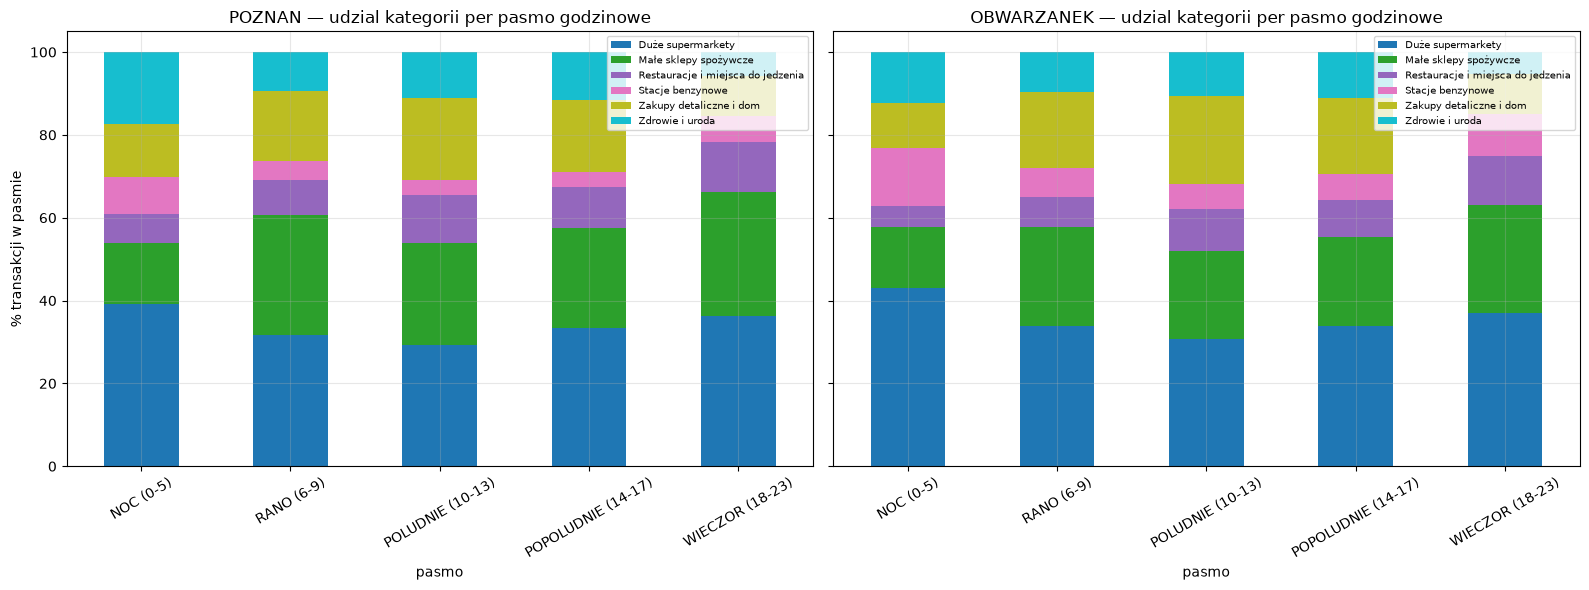

In [10]:
PASMA_ORDER = ['NOC (0-5)', 'RANO (6-9)', 'POLUDNIE (10-13)', 'POPOLUDNIE (14-17)', 'WIECZOR (18-23)']

def przypisz_pasmo(godz):
    if 0 <= godz <= 5:
        return 'NOC (0-5)'
    if 6 <= godz <= 9:
        return 'RANO (6-9)'
    if 10 <= godz <= 13:
        return 'POLUDNIE (10-13)'
    if 14 <= godz <= 17:
        return 'POPOLUDNIE (14-17)'
    return 'WIECZOR (18-23)'

df_godz_mcc['pasmo'] = df_godz_mcc['godzina'].map(przypisz_pasmo)

df_pasma = df_godz_mcc.groupby(['grupa_analizy', 'pasmo', 'kategoria_glowna'], as_index=False).agg(
    transakcje=('transakcje', 'sum'), wolumen=('wolumen', 'sum'))
df_pasma['srednia_transakcja'] = df_pasma['wolumen'] / df_pasma['transakcje']
df_pasma.to_csv(f'{OUT_DIR}/05_pasma_x_kategorie.csv', index=False, encoding='utf-8-sig')

# udzial kazdej kategorii w kazdym pasmie, per grupa
top5 = df_pasma.groupby('kategoria_glowna')['transakcje'].sum().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, grupa in zip(axes, ['POZNAN', 'OBWARZANEK']):
    sub = df_pasma[(df_pasma['grupa_analizy'] == grupa) & (df_pasma['kategoria_glowna'].isin(top5))]
    piv = sub.pivot_table(index='pasmo', columns='kategoria_glowna', values='transakcje', aggfunc='sum', fill_value=0)
    piv = piv.reindex(PASMA_ORDER)
    piv_pct = piv.div(piv.sum(axis=1), axis=0) * 100
    piv_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title(f'{grupa} — udzial kategorii per pasmo godzinowe')
    ax.set_ylabel('% transakcji w pasmie')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7, loc='upper right')
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/05_pasma_udzial_kategorii.png', dpi=120)
plt.show()


## 6. Trend miesięczny — POZNAN vs OBWARZANEK

**Uwaga (jakość danych) — pipeline wzbogacania `lau_enr` degraduje się od lutego 2026:**

| Miesiąc | % rekordów z NULL w `lau_enr` | Status |
|---|---|---|
| 2025-01 do 2026-01 | ~1.4–1.8% | normalne |
| 2026-02 | 4.3% | lekko podwyższone |
| **2026-03** | **93.4%** | praktycznie brak wzbogacenia |
| 2026-04 | 4.3% | lekko podwyższone (odzyskane) |
| **2026-05** | **100%** | **brak wzbogacenia w ogóle** |
| **2026-06** | **100%** | **brak wzbogacenia w ogóle** |

Sam wolumen transakcji (dane merchant-side) jest normalny przez cały okres — problem
dotyczy wyłącznie przypisania miejsca zamieszkania karty (`lau_enr`), na którym oparta
jest cała ta analiza (POZNAN vs OBWARZANEK). W praktyce: **maj i czerwiec 2026 są całkowicie
nieobecne** we wszystkich sekcjach tego notatnika (1–10), a marzec 2026 wykluczony jest
explicité z trendu poniżej (dostępne dla niego ~6,6% rekordów nie jest reprezentatywną próbką).
Realny zakres danych o mieszkańcach: **2025-01 do 2026-04** (~16 z 18 nominalnych miesięcy).
Nie wpływa to na porównanie POZNAN vs OBWARZANEK (obie grupy dotyczy ten sam problem
proporcjonalnie), ale ogranicza zakres czasowy wniosków o trendzie.

In [11]:
df_trend = duckdb.sql(f"""
    SELECT
        prch_mnth_id AS miesiac,
        {GRUPA_CASE} AS grupa_analizy,
        COUNT(*) AS transakcje,
        SUM(cs_tran_amt) AS wolumen,
        ROUND(SUM(cs_tran_amt) / COUNT(*), 2) AS srednia_transakcja,
        COUNT(DISTINCT pymt_crd_acct_num_raw) AS unikalne_karty
    FROM '{PATH}'
    WHERE {FILTR_METRO} AND prch_mnth_id <> 202603
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()
df_trend['transakcji_na_karte'] = df_trend['transakcje'] / df_trend['unikalne_karty']
df_trend.to_csv(f'{OUT_DIR}/06_trend_miesieczny.csv', index=False, encoding='utf-8-sig')
df_trend.head(10)


,miesiac,grupa_analizy,transakcje,wolumen,srednia_transakcja,unikalne_karty,transakcji_na_karte
0,202501,OBWARZANEK,1050993,1.453145e+08,138.26,62166,16.906235
1,202501,POZNAN,1462324,1.638620e+08,112.06,75918,19.261888
2,202502,OBWARZANEK,1000962,1.421292e+08,141.99,62857,15.924432
3,202502,POZNAN,1345019,1.506362e+08,112.00,75398,17.838921
4,202503,OBWARZANEK,1217736,1.674262e+08,137.49,64479,18.885777
5,202503,POZNAN,1629707,1.705595e+08,104.66,75323,21.636247
6,202504,OBWARZANEK,1288592,1.873545e+08,145.39,66762,19.301279
7,202504,POZNAN,1638855,1.849997e+08,112.88,75001,21.851109
8,202505,OBWARZANEK,1297600,1.812571e+08,139.69,67671,19.175127
9,202505,POZNAN,1600970,1.783220e+08,111.38,74064,21.616035


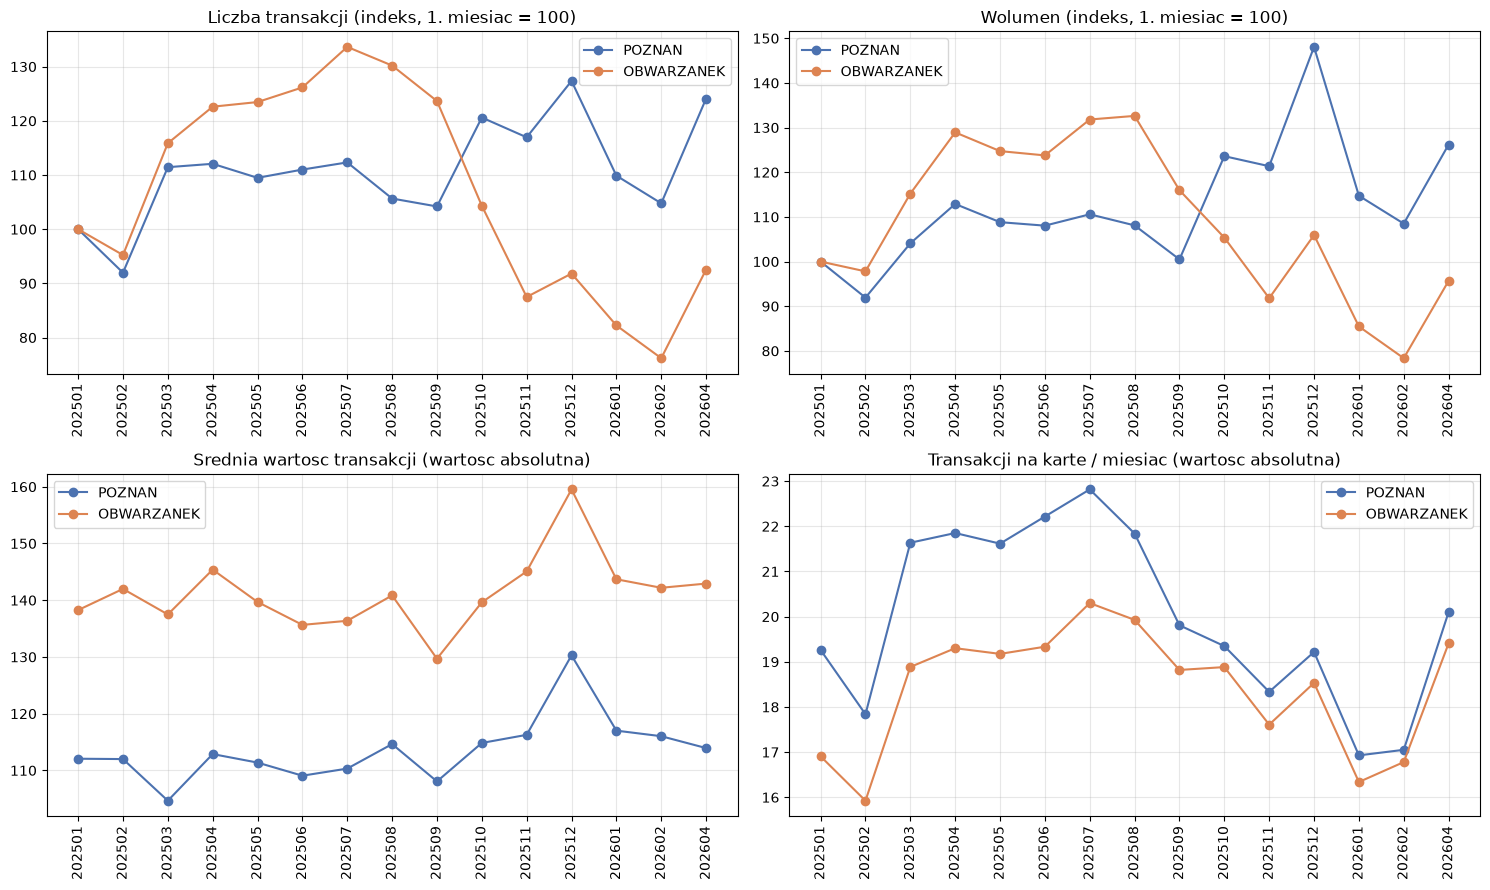

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
metryki = [
    ('transakcje', 'Liczba transakcji (indeks, 1. miesiac = 100)'),
    ('wolumen', 'Wolumen (indeks, 1. miesiac = 100)'),
    ('srednia_transakcja', 'Srednia wartosc transakcji (wartosc absolutna)'),
    ('transakcji_na_karte', 'Transakcji na karte / miesiac (wartosc absolutna)'),
]
for ax, (col, title) in zip(axes.flat, metryki):
    for grupa, kolor in [('POZNAN', '#4C72B0'), ('OBWARZANEK', '#DD8452')]:
        sub = df_trend[df_trend['grupa_analizy'] == grupa].sort_values('miesiac')
        y = sub[col].values
        if 'indeks' in title:
            y = 100 * y / y[0]
        ax.plot(sub['miesiac'].astype(str), y, marker='o', label=grupa, color=kolor)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.legend()
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/06_trend_miesieczny.png', dpi=120)
plt.show()


## 7. Koncentracja wydatków (Pareto) — ile kart generuje 50%/80% wolumenu

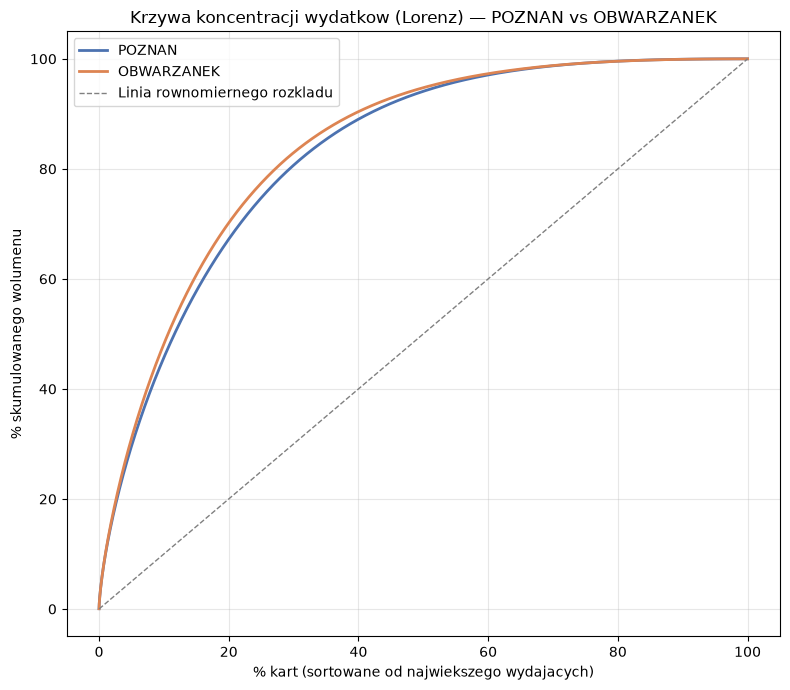

,grupa_analizy,liczba_kart,pct_kart_do_50pct_wolumenu,pct_kart_do_80pct_wolumenu
0,POZNAN,179360,11.63,29.38
1,OBWARZANEK,144440,10.64,27.18


In [13]:
df_karty_wolumen = duckdb.sql(f"""
    SELECT
        {GRUPA_CASE} AS grupa_analizy,
        pymt_crd_acct_num_raw AS karta,
        SUM(cs_tran_amt) AS wolumen_karty
    FROM '{PATH}'
    WHERE {FILTR_METRO}
    GROUP BY 1, 2
""").df()

pareto_wyniki = []
fig, ax = plt.subplots(figsize=(8, 7))
for grupa, kolor in [('POZNAN', '#4C72B0'), ('OBWARZANEK', '#DD8452')]:
    sub = df_karty_wolumen[df_karty_wolumen['grupa_analizy'] == grupa].sort_values('wolumen_karty', ascending=False)
    sub = sub.reset_index(drop=True)
    n = len(sub)
    cum_wolumen_pct = 100 * sub['wolumen_karty'].cumsum() / sub['wolumen_karty'].sum()
    cum_karty_pct = 100 * (sub.index + 1) / n

    karty_do_50 = (cum_wolumen_pct >= 50).idxmax()
    karty_do_80 = (cum_wolumen_pct >= 80).idxmax()
    pct_karty_50 = 100 * (karty_do_50 + 1) / n
    pct_karty_80 = 100 * (karty_do_80 + 1) / n
    pareto_wyniki.append({'grupa_analizy': grupa, 'liczba_kart': n,
                          'pct_kart_do_50pct_wolumenu': round(pct_karty_50, 2),
                          'pct_kart_do_80pct_wolumenu': round(pct_karty_80, 2)})

    ax.plot(cum_karty_pct, cum_wolumen_pct, label=grupa, color=kolor, linewidth=2)

ax.plot([0, 100], [0, 100], linestyle='--', color='gray', linewidth=1, label='Linia rownomiernego rozkladu')
ax.set_xlabel('% kart (sortowane od najwiekszego wydajacych)')
ax.set_ylabel('% skumulowanego wolumenu')
ax.set_title('Krzywa koncentracji wydatkow (Lorenz) — POZNAN vs OBWARZANEK')
ax.legend()
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/07_pareto_koncentracja.png', dpi=120)
plt.show()

df_pareto = pd.DataFrame(pareto_wyniki)
df_pareto.to_csv(f'{OUT_DIR}/07_pareto_koncentracja.csv', index=False, encoding='utf-8-sig')
df_pareto


## 8. Rozkład percentylowy wartości transakcji

In [14]:
df_percentyle = duckdb.sql(f"""
    SELECT
        {GRUPA_CASE} AS grupa_analizy,
        ROUND(quantile_cont(cs_tran_amt, 0.25), 2) AS p25,
        ROUND(quantile_cont(cs_tran_amt, 0.50), 2) AS p50_mediana,
        ROUND(quantile_cont(cs_tran_amt, 0.75), 2) AS p75,
        ROUND(quantile_cont(cs_tran_amt, 0.90), 2) AS p90,
        ROUND(quantile_cont(cs_tran_amt, 0.99), 2) AS p99,
        ROUND(AVG(cs_tran_amt), 2) AS srednia
    FROM '{PATH}'
    WHERE {FILTR_METRO}
    GROUP BY 1
    ORDER BY 1
""").df()
df_percentyle.to_csv(f'{OUT_DIR}/08_percentyle.csv', index=False, encoding='utf-8-sig')
df_percentyle


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,grupa_analizy,p25,p50_mediana,p75,p90,p99,srednia
0,OBWARZANEK,18.68,52.70,138.05,319.7,1195.98,140.71
1,POZNAN,15.37,41.76,106.70,248.6,1021.20,113.80


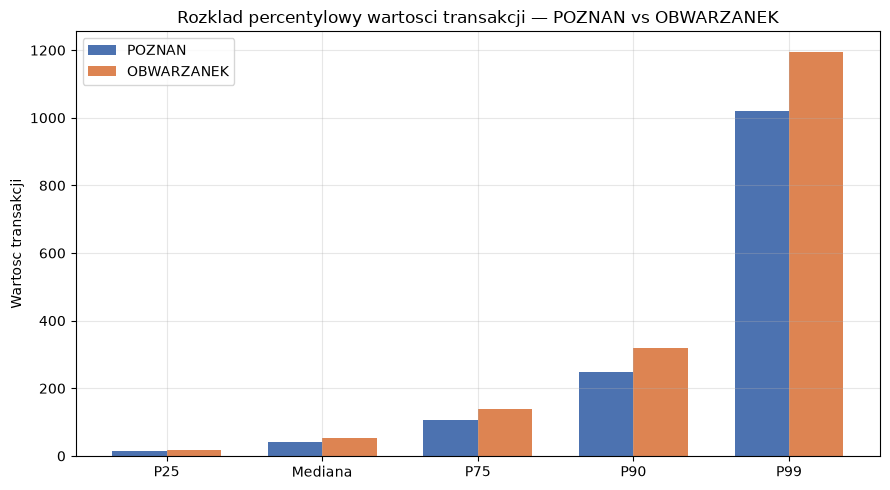

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
kolumny_pct = ['p25', 'p50_mediana', 'p75', 'p90', 'p99']
x = np.arange(len(kolumny_pct))
width = 0.35
for i, (grupa, kolor) in enumerate([('POZNAN', '#4C72B0'), ('OBWARZANEK', '#DD8452')]):
    row = df_percentyle[df_percentyle['grupa_analizy'] == grupa].iloc[0]
    ax.bar(x + (i - 0.5) * width, [row[c] for c in kolumny_pct], width, label=grupa, color=kolor)
ax.set_xticks(x)
ax.set_xticklabels(['P25', 'Mediana', 'P75', 'P90', 'P99'])
ax.set_ylabel('Wartosc transakcji')
ax.set_title('Rozklad percentylowy wartosci transakcji — POZNAN vs OBWARZANEK')
ax.legend()
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/08_percentyle.png', dpi=120)
plt.show()


## 9. TOP kraje zagraniczne — dokąd jeżdżą mieszkańcy

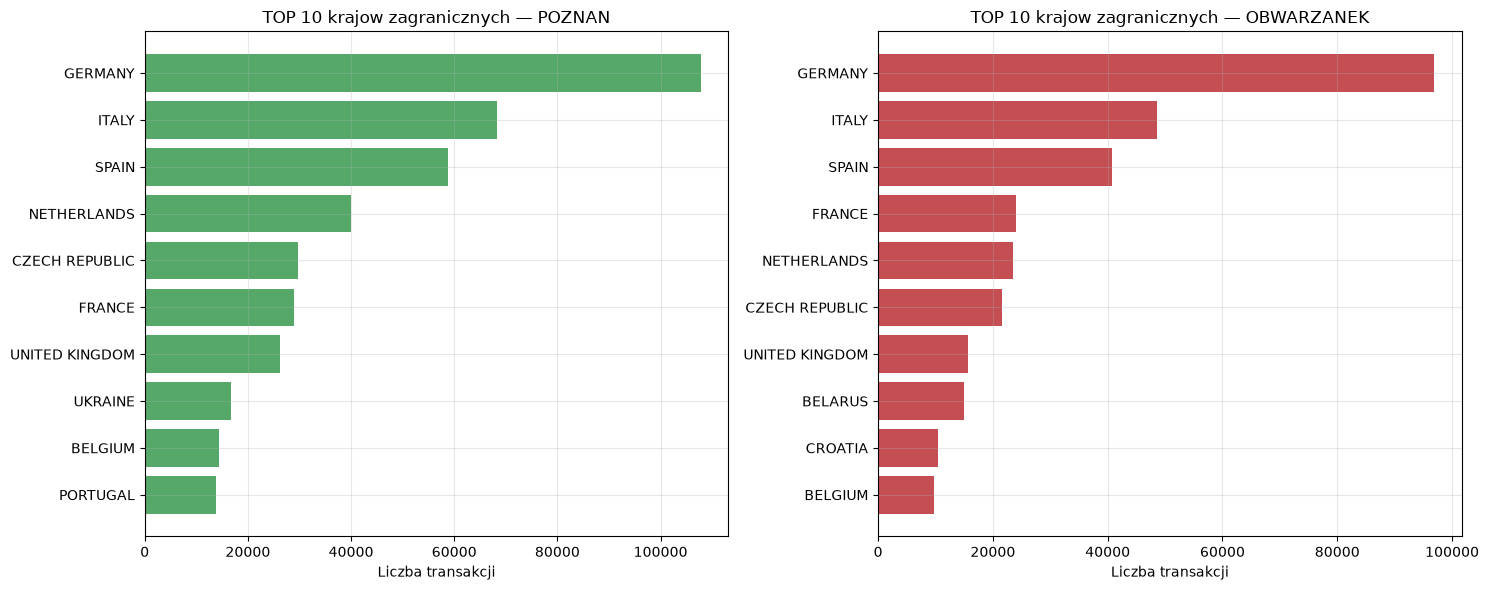

In [16]:
df_kraje = duckdb.sql(f"""
    SELECT
        {GRUPA_CASE} AS grupa_analizy,
        mrch_ctry_nm AS kraj,
        COUNT(*) AS transakcje,
        SUM(cs_tran_amt) AS wolumen
    FROM '{PATH}'
    WHERE {FILTR_METRO} AND mrch_ctry_nm <> 'POLAND'
    GROUP BY 1, 2
""").df()
df_kraje.to_csv(f'{OUT_DIR}/09_top_kraje.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, grupa in zip(axes, ['POZNAN', 'OBWARZANEK']):
    sub = df_kraje[df_kraje['grupa_analizy'] == grupa].sort_values('transakcje', ascending=False).head(10)
    sub = sub.sort_values('transakcje')
    ax.barh(sub['kraj'], sub['transakcje'], color='#55A868' if grupa == 'POZNAN' else '#C44E52')
    ax.set_title(f'TOP 10 krajow zagranicznych — {grupa}')
    ax.set_xlabel('Liczba transakcji')
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/09_top_kraje.png', dpi=120)
plt.show()


## 10. Wnioski biznesowe (liczone automatycznie z danych powyzej)

In [17]:
wnioski = []

wnioski.append(
    "0. [JAKOSC DANYCH] Pipeline wzbogacania lau_enr degraduje sie od 2026-02: 2026-02=4.3% NULL, "
    "2026-03=93.4% NULL, 2026-04=4.3% NULL (odzyskane), 2026-05=100% NULL, 2026-06=100% NULL (norma ~1.5%). "
    "Maj/czerwiec 2026 sa calkowicie nieobecne we WSZYSTKICH sekcjach (1-10), marzec 2026 explicite "
    "wykluczony z trendu (sekcja 6). Realny zakres danych o mieszkancach: 2025-01 do 2026-04 (~16/18 mies.). "
    "Nie wplywa to na porownanie POZNAN vs OBWARZANEK (ten sam problem dotyczy obu grup proporcjonalnie)."
)

def pct_diff(a, b):
    return 100 * (a - b) / b if b else float('nan')

# --- 1. Roznica sredniej wartosci transakcji POZNAN vs OBWARZANEK (ogolnie) ---
sr_poznan = df_baza.loc[df_baza['grupa_analizy'] == 'POZNAN', 'srednia_transakcja'].iloc[0]
sr_obwarz = df_baza.loc[df_baza['grupa_analizy'] == 'OBWARZANEK', 'srednia_transakcja'].iloc[0]
diff = pct_diff(sr_obwarz, sr_poznan)
kto_wiecej = 'OBWARZANEK' if diff > 0 else 'POZNAN'
wnioski.append(
    f"1. Srednia wartosc transakcji: POZNAN={sr_poznan:.2f}, OBWARZANEK={sr_obwarz:.2f} "
    f"-> mieszkancy {kto_wiecej} wydaja na transakcje {abs(diff):.1f}% wiecej."
)

# --- 2. Roznice sredniej wg lokalizacji (w Poznaniu / Polska poza Poznaniem / za granica) ---
for grupa in ['POZNAN', 'OBWARZANEK']:
    row = df_lokalizacja[df_lokalizacja['grupa_analizy'] == grupa].iloc[0]
    lokalizacje = {
        'w Poznaniu': row['srednia_w_poznaniu'],
        'Polska poza Poznaniem': row['srednia_polska_poza_poznaniem'],
        'za granica': row['srednia_za_granica'],
    }
    najwyzsza = max(lokalizacje, key=lokalizacje.get)
    najnizsza = min(lokalizacje, key=lokalizacje.get)
    wnioski.append(
        f"2. [{grupa}] najwyzsza srednia transakcja: {najwyzsza} ({lokalizacje[najwyzsza]:.2f}), "
        f"najnizsza: {najnizsza} ({lokalizacje[najnizsza]:.2f}) "
        f"-> transakcje {najwyzsza} sa {pct_diff(lokalizacje[najwyzsza], lokalizacje[najnizsza]):.0f}% wieksze niz {najnizsza}."
    )

# --- 3. Udzial transakcji za granica (skala zjawiska) ---
for grupa in ['POZNAN', 'OBWARZANEK']:
    row = df_lokalizacja[df_lokalizacja['grupa_analizy'] == grupa].iloc[0]
    total_grupa = row['transakcje_w_poznaniu'] + row['transakcje_polska_poza_poznaniem'] + row['transakcje_za_granica']
    udzial_zagr = 100 * row['transakcje_za_granica'] / total_grupa
    wnioski.append(f"3. [{grupa}] udzial transakcji za granica: {udzial_zagr:.2f}% wszystkich transakcji tej grupy.")

# --- 4. Weekend vs dzien roboczy - roznica sredniej wartosci transakcji ---
for grupa in ['POZNAN', 'OBWARZANEK']:
    sub = df_dni[df_dni['grupa_analizy'] == grupa]
    roboczy = sub[sub['typ_dnia'] == 'DZIEN ROBOCZY']['srednia_transakcja'].mean()
    weekend = sub[sub['typ_dnia'] == 'WEEKEND']['srednia_transakcja'].mean()
    wnioski.append(
        f"4. [{grupa}] srednia transakcja: dzien roboczy={roboczy:.2f}, weekend={weekend:.2f} "
        f"-> weekend {'wyzszy' if weekend > roboczy else 'nizszy'} o {abs(pct_diff(weekend, roboczy)):.1f}%."
    )

# --- 5. Kategorie MCC najbardziej nad-/pod-reprezentowane w OBWARZANKU vs POZNANIU ---
udzial = df_godz_mcc.groupby(['grupa_analizy', 'kategoria_glowna'])['transakcje'].sum().reset_index()
totals_grupa = udzial.groupby('grupa_analizy')['transakcje'].sum().to_dict()
udzial['pct'] = udzial.apply(lambda r: 100 * r['transakcje'] / totals_grupa[r['grupa_analizy']], axis=1)
piv_udzial = udzial.pivot(index='kategoria_glowna', columns='grupa_analizy', values='pct').fillna(0)
piv_udzial['delta_obwarzanek_minus_poznan'] = piv_udzial.get('OBWARZANEK', 0) - piv_udzial.get('POZNAN', 0)
top_nadreprezentowane = piv_udzial.sort_values('delta_obwarzanek_minus_poznan', ascending=False).head(3)
top_podreprezentowane = piv_udzial.sort_values('delta_obwarzanek_minus_poznan', ascending=True).head(3)

wnioski.append("5. Kategorie MCC NAD-reprezentowane w OBWARZANKU (wzgledem POZNANIA):")
for kat, row in top_nadreprezentowane.iterrows():
    wnioski.append(f"   - {kat}: OBWARZANEK {row.get('OBWARZANEK', 0):.2f}% vs POZNAN {row.get('POZNAN', 0):.2f}% (delta {row['delta_obwarzanek_minus_poznan']:+.2f} p.p.)")

wnioski.append("5b. Kategorie MCC NAD-reprezentowane w POZNANIU (wzgledem OBWARZANKA):")
for kat, row in top_podreprezentowane.iterrows():
    wnioski.append(f"   - {kat}: POZNAN {row.get('POZNAN', 0):.2f}% vs OBWARZANEK {row.get('OBWARZANEK', 0):.2f}% (delta {-row['delta_obwarzanek_minus_poznan']:+.2f} p.p.)")

# --- 6. Pasmo godzinowe z najwyzszym udzialem transakcji, per grupa ---
pasmo_udzial = df_pasma.groupby(['grupa_analizy', 'pasmo'])['transakcje'].sum().reset_index()
for grupa in ['POZNAN', 'OBWARZANEK']:
    sub = pasmo_udzial[pasmo_udzial['grupa_analizy'] == grupa]
    top_pasmo = sub.loc[sub['transakcje'].idxmax()]
    udzial_pct = 100 * top_pasmo['transakcje'] / sub['transakcje'].sum()
    wnioski.append(f"6. [{grupa}] dominujace pasmo godzinowe: {top_pasmo['pasmo']} ({udzial_pct:.1f}% transakcji).")

# --- 7. Trend miesieczny - miesiac z najwieksza rozbieznoscia liczby transakcji (indeksowanej) ---
piv_trend = df_trend.pivot(index='miesiac', columns='grupa_analizy', values='transakcje')
piv_idx = 100 * piv_trend / piv_trend.iloc[0]
rozbieznosc = (piv_idx['OBWARZANEK'] - piv_idx['POZNAN']).abs()
miesiac_max_rozbieznosci = rozbieznosc.idxmax()
wnioski.append(
    f"7. Najwieksza rozbieznosc trendu (indeks liczby transakcji, 1. miesiac=100) miedzy grupami: "
    f"miesiac {miesiac_max_rozbieznosci} (POZNAN={piv_idx.loc[miesiac_max_rozbieznosci, 'POZNAN']:.1f}, "
    f"OBWARZANEK={piv_idx.loc[miesiac_max_rozbieznosci, 'OBWARZANEK']:.1f})."
)
wzrost_poznan = piv_idx['POZNAN'].iloc[-1] - 100
wzrost_obwarz = piv_idx['OBWARZANEK'].iloc[-1] - 100
wnioski.append(
    f"7b. Wzrost liczby transakcji od 1. do ostatniego miesiaca: POZNAN {wzrost_poznan:+.1f}%, "
    f"OBWARZANEK {wzrost_obwarz:+.1f}% -> {'OBWARZANEK rosnie szybciej' if wzrost_obwarz > wzrost_poznan else 'POZNAN rosnie szybciej'}."
)

# --- 8. Koncentracja wydatkow (Pareto) ---
for _, row in df_pareto.iterrows():
    wnioski.append(
        f"8. [{row['grupa_analizy']}] {row['pct_kart_do_50pct_wolumenu']:.1f}% kart generuje 50% wolumenu, "
        f"{row['pct_kart_do_80pct_wolumenu']:.1f}% kart generuje 80% wolumenu (z {row['liczba_kart']:,} kart)."
    )

# --- 9. Rozklad percentylowy - rozpietosc (P99 vs mediana) ---
for _, row in df_percentyle.iterrows():
    rozpietosc = row['p99'] / row['p50_mediana']
    wnioski.append(
        f"9. [{row['grupa_analizy']}] mediana={row['p50_mediana']:.2f}, P90={row['p90']:.2f}, P99={row['p99']:.2f} "
        f"-> transakcje z top 1% sa {rozpietosc:.1f}x wieksze niz mediana (silnie prawoskosny rozklad)."
    )

# --- 10. TOP kraj zagraniczny per grupa ---
for grupa in ['POZNAN', 'OBWARZANEK']:
    sub = df_kraje[df_kraje['grupa_analizy'] == grupa].sort_values('transakcje', ascending=False)
    if len(sub) > 0:
        top = sub.iloc[0]
        total_zagr = sub['transakcje'].sum()
        wnioski.append(
            f"10. [{grupa}] najczesciej odwiedzany kraj zagraniczny: {top['kraj']} "
            f"({100 * top['transakcje'] / total_zagr:.1f}% wszystkich transakcji zagranicznych tej grupy)."
        )

print(chr(10).join(wnioski))

with open(f'{OUT_DIR}/wnioski_biznesowe.txt', 'w', encoding='utf-8') as f:
    f.write(chr(10).join(wnioski))
print()
print(f'Zapisano: {OUT_DIR}/wnioski_biznesowe.txt')


0. [JAKOSC DANYCH] Pipeline wzbogacania lau_enr degraduje sie od 2026-02: 2026-02=4.3% NULL, 2026-03=93.4% NULL, 2026-04=4.3% NULL (odzyskane), 2026-05=100% NULL, 2026-06=100% NULL (norma ~1.5%). Maj/czerwiec 2026 sa calkowicie nieobecne we WSZYSTKICH sekcjach (1-10), marzec 2026 explicite wykluczony z trendu (sekcja 6). Realny zakres danych o mieszkancach: 2025-01 do 2026-04 (~16/18 mies.). Nie wplywa to na porownanie POZNAN vs OBWARZANEK (ten sam problem dotyczy obu grup proporcjonalnie).
1. Srednia wartosc transakcji: POZNAN=113.80, OBWARZANEK=140.71 -> mieszkancy OBWARZANEK wydaja na transakcje 23.6% wiecej.
2. [POZNAN] najwyzsza srednia transakcja: za granica (174.95), najnizsza: w Poznaniu (111.39) -> transakcje za granica sa 57% wieksze niz w Poznaniu.
2. [OBWARZANEK] najwyzsza srednia transakcja: za granica (188.66), najnizsza: Polska poza Poznaniem (134.45) -> transakcje za granica sa 40% wieksze niz Polska poza Poznaniem.
3. [POZNAN] udzial transakcji za granica: 2.40% wszyst

Powiazane pliki (ten sam folder):
- `01_statystyki_podstawowe.csv/.png`
- `02_lokalizacja_transakcji.csv`, `02_srednie_wg_lokalizacji.png`
- `03_dni_robocze_weekend.csv/.png`
- `04_godziny_x_mcc.csv`, `04_heatmapa_godziny_mcc.png`
- `05_pasma_x_kategorie.csv`, `05_pasma_udzial_kategorii.png`
- `06_trend_miesieczny.csv/.png`
- `07_pareto_koncentracja.csv/.png`
- `08_percentyle.csv/.png`
- `09_top_kraje.csv/.png`
- `wnioski_biznesowe.txt`